OBJETIVO DE RIESGO DE CREDITO - PROBABILIDAD DE INCUPLIMIENTO Y CALCULAR PERDIDA ESPERADAS

RUTA : riesgo crediticio en 3 fases.

1. Importación de librerías
2. Carga de datos
3. Análisis exploratorio
4. Limpieza de datos
---------------------------------
5. Ingeniería de variables
6. División Train/Test
7. Entrenamiento Random Forest
8. Evaluación
9. Importancia de variables
--------------------------------
10. Función Expected Loss
11. Conclusiones

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Configuración de gráficos
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

df = pd.read_csv("task3.csv")

df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'task3.csv'

In [ ]:
df.info() #tipos de datos , nulos y numero de filas y columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [ ]:
df.describe() #estadisticas de las columnas numericas

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [ ]:
df.isnull().sum() #verificar si hay valores nulos

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Analisis exploratorio basico EDA


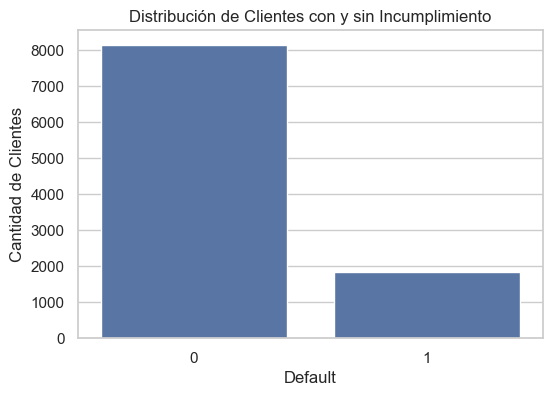

default
0    8149
1    1851
Name: count, dtype: int64

Porcentaje:
default
0    81.49
1    18.51
Name: proportion, dtype: float64


In [ ]:
#distribución de clientes con y sin incumplimiento
# 0 = no incumplimiento 1 = incumplimiento

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="default")

plt.title("Distribución de Clientes con y sin Incumplimiento")
plt.xlabel("Default")
plt.ylabel("Cantidad de Clientes")

plt.show()

print(df["default"].value_counts())

print("\nPorcentaje:")

print(df["default"].value_counts(normalize=True)*100)

Conclusión: La variable objetivo presenta un desbalance moderado: el 81.49% de los clientes no incurrieron en incumplimiento, mientras que el 18.51% sí lo hicieron. Este comportamiento es consistente con escenarios reales de riesgo crediticio, donde los eventos de default son menos frecuentes. Debido a que el desbalance no es extremo, inicialmente se entrenará el modelo sin técnicas de remuestreo, evaluando posteriormente su capacidad para identificar correctamente la clase minoritaria

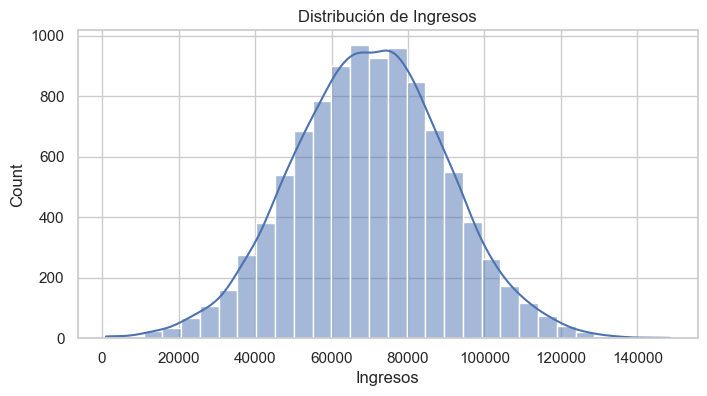

In [ ]:
#histograma de ingresos 
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="income", bins=30, kde=True)
plt.title("Distribución de Ingresos")
plt.xlabel("Ingresos")
plt.show()  

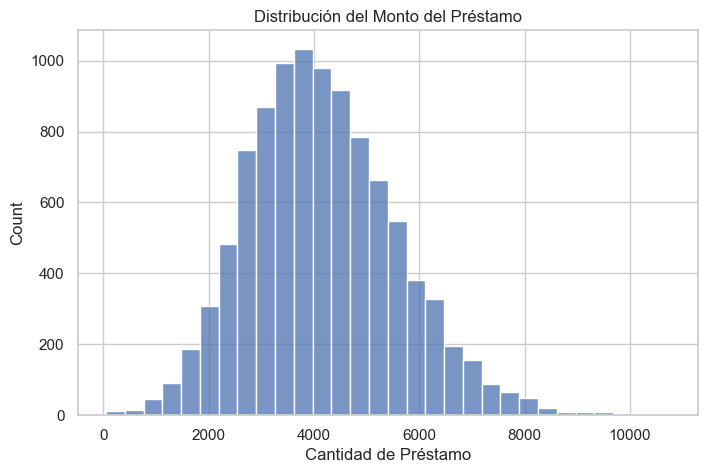

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["loan_amt_outstanding"], bins=30)

plt.title("Distribución del Monto del Préstamo")

plt.xlabel("Cantidad de Préstamo")

plt.show()

#tipos de prestamos en cantidad ? 

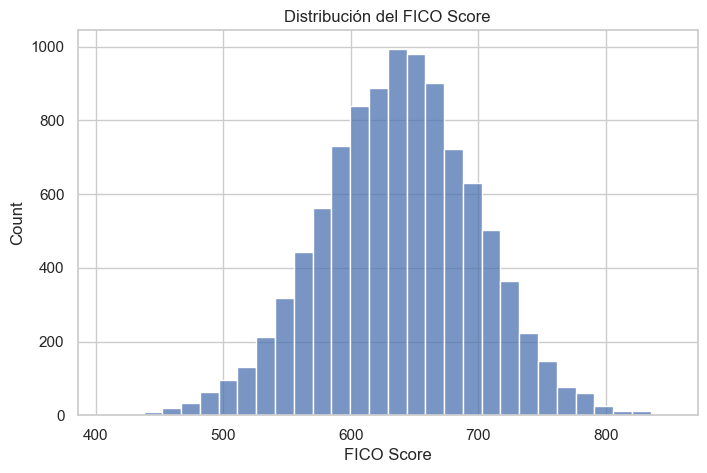

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["fico_score"], bins=30)

plt.title("Distribución del FICO Score")

plt.xlabel("FICO Score")

plt.show()

#el FICO score es un puntaje de crédito que se utiliza para evaluar la solvencia crediticia de una persona. Se basa en el historial crediticio y otros factores financieros, y generalmente varía entre 300 y 850. Un puntaje más alto indica un menor riesgo de incumplimiento, mientras que un puntaje más bajo sugiere un mayor riesgo.


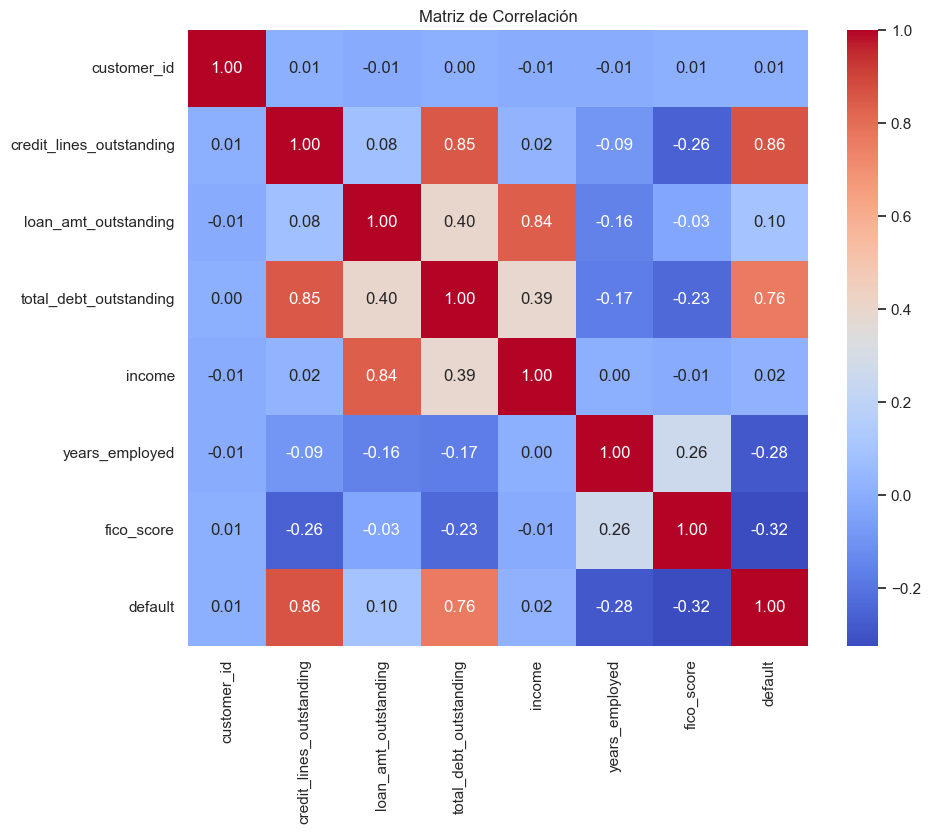

In [ ]:
plt.figure(figsize=(10,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación")

plt.show()

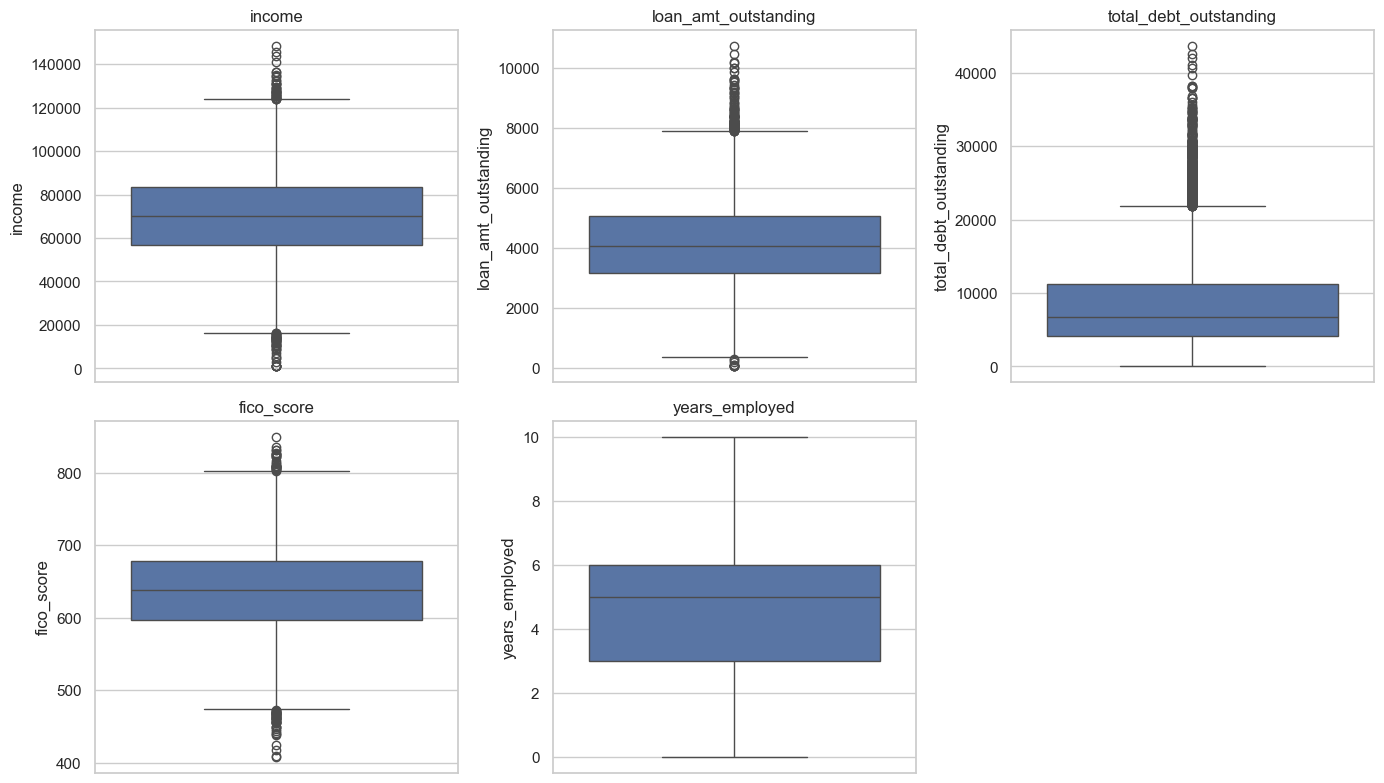

In [ ]:
numerical_columns = [
    "income",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "fico_score",
    "years_employed"
]

plt.figure(figsize=(14,8))

for i, column in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()

plt.show()

Preparacion de datos 

In [ ]:
# Variables predictoras
X = df.drop(columns=["customer_id", "default"])

# Variable objetivo
y = df["default"]

print("Variables predictoras:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
Index(['credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score'],
      dtype='object')

Variable objetivo:
default


-División 80% entrenamiento / 20% prueba.
-Uso de stratify=y para mantener el mismo porcentaje de clientes en default en ambos conjuntos.
-random_state=42 para que los resultados sean reproducibles.
Un Random Forest configurado con hiperparámetros razonables desde el inicio.

PASO- ENTRENAMIENTO DEL MODELO

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Conjunto de entrenamiento:", x_train.shape)
print("Conjunto de prueba:", x_test.shape)

Conjunto de entrenamiento: (8000, 6)
Conjunto de prueba: (2000, 6)


In [ ]:
#usamos una conf muy profesional para el modelo de random forest

rf=RandomForestClassifier(
n_estimators=300, #construye 300 arboles de decision , mejor estabilidad de prediccion
max_depth=10, # limiita la profundidad de los arboles para evitar sobreajuste
min_samples_split=10, #exige al menos 10 muestras para dividir un nodo, evitando divisiones triviales
min_samples_leaf=5, #evita hojas con muy pocas muestras, lo que mejora la generalización
random_state=42, #garantiza reproducibilidad de los resultados
n_jobs=-1 # utiliza todos los núcleos de CPU disponibles para acelerar el entrenamiento
)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

Evaluacion de modelo 
y_pred = modelo.predict(x_test) # predict() devuelve unicamente la clase
y_prob = modelo.predict(x_test)[:,1] predict_proba() devuelve la probabilidad

In [ ]:
y_pred = rf.predict(x_test)

# Probabilidad de Default (PD)

y_prob = rf.predict_proba(x_test)[:,1]
#y_prob representa la probabilidad de default , sera utilizada mas adelante para calcular la perdida esperada(expected loss)

ACCURACY 

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.4f}")

Precisión del modelo: 0.9950


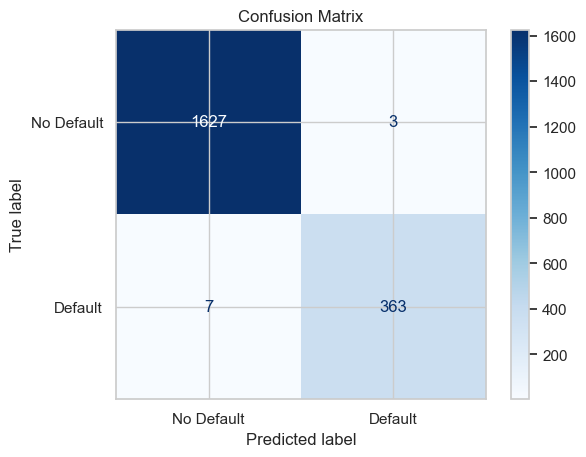

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default","Default"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

TN = true negative TP = true positive
FP = False positive FN = False Negative

los no default  ( 7 ) clientes que realmente incumplieron pero el modelo no detecto
 es el error mas costoso para un banco, porque el banco aprobo un credito  a un cliente que termino incumpliendo
 por eso se busca recortar los false negative

classication report


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Default","Default"]))

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1630
     Default       0.99      0.98      0.99       370

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



significados :
precision : responde de todos los clientes que el modelo dijo que incumplieran
recall : de todo los clientes que realmente incumplieron
F1 Score : es un equilibrio entre precision y recall

In [ ]:
#ROC - AUC es una métrica que evalúa la capacidad de un modelo para distinguir entre clases. Un valor de AUC cercano a 1 indica un excelente rendimiento, mientras que un valor cercano a 0.5 sugiere un rendimiento similar al azar.
auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc:.4f}")

# mayor a 0.85 suele ser un buen resultado para modelos de riesgos crediticios.

ROC AUC Score: 0.9998


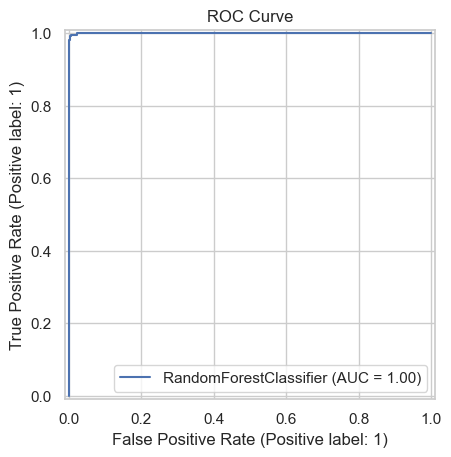

In [ ]:
RocCurveDisplay.from_estimator(
    rf,
    x_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

                   Variable  Importancia
0  credit_lines_outstanding     0.582563
2    total_debt_outstanding     0.302967
4            years_employed     0.046301
5                fico_score     0.034156
3                    income     0.023973
1      loan_amt_outstanding     0.010040


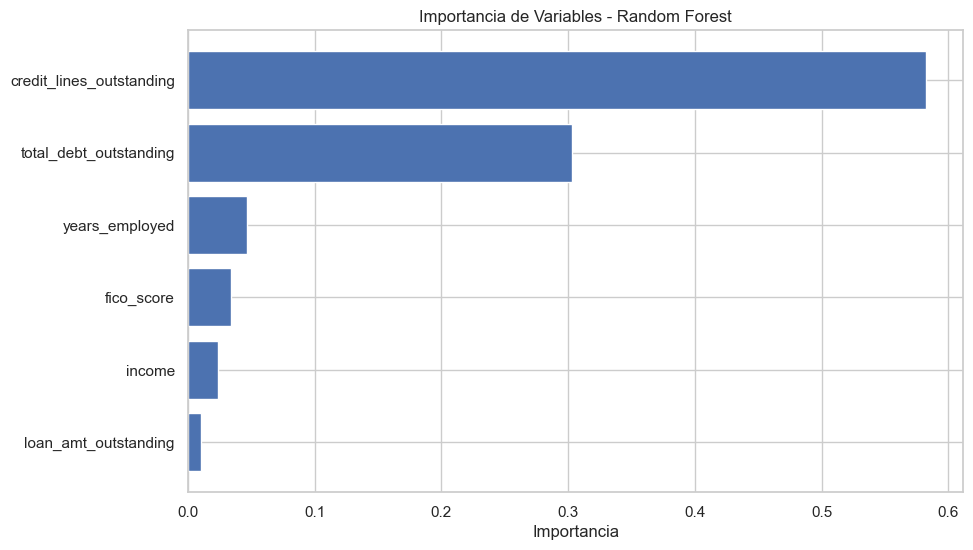

In [ ]:
#con esto podemos ver la importancia de cada variable en el modelo de Random Forest, lo que nos permite identificar cuáles son los factores más relevantes para predecir el incumplimiento crediticio.
#con las primeras dos 2 variables podemos ver el 88% de la importancia total

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Variable"],
    feature_importance["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Importancia de Variables - Random Forest")

plt.xlabel("Importancia")

plt.show()

VALIDACION CRUZADA

In [ ]:
# ============================
# VALIDACIÓN CRUZADA    # Es para re cofirmar la estabilidad del modelo y su capacidad de generalización a nuevos datos. Se divide el conjunto de datos en varios subconjuntos (folds) y se entrena y evalúa el modelo en cada uno de ellos, proporcionando una estimación más robusta del rendimiento.
# ============================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC por fold:")
print(cv_scores)

print("\nROC-AUC promedio:")
print(cv_scores.mean())

print("\nDesviación estándar:")
print(cv_scores.std())

ROC-AUC por fold:
[0.99985409 0.99986901 0.99962527 0.9997745  0.99978324]

ROC-AUC promedio:
0.9997812213228503

Desviación estándar:
8.647147256832612e-05


PASO 10 POR REALIZAR 

Creacion de la funcion de expected_loss()
una funcion para que calcule automaticamente la perdida esperada con tasa de recuperacion al 10%
expectedloss = PD x LGD x EAD
pd = probability of default : la que predice nuestro Random forest
lgd = loss given default : porcentaje de perdida si el cliente incumple 10%
ead = exposure at default : monto expuesto al riesgo (en este caso : loan_amt_outstanding)

In [ ]:
#funcion de perdida esperada (expected loss)
RECOVERY_RATE = 0.10
LGD = 1 - RECOVERY_RATE


def calcular_perdida_esperada(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score
):
    """
    Calcula la Probabilidad de Default (PD)
    y la Pérdida Esperada (Expected Loss)
    utilizando el modelo Random Forest.

    Parámetros
    ----------
    credit_lines_outstanding : int
    loan_amt_outstanding : float
    total_debt_outstanding : float
    income : float
    years_employed : float
    fico_score : int

    Retorna
    -------
    dict
        Diccionario con la PD, LGD y Expected Loss.
    """

    # Crear un DataFrame con los datos del nuevo cliente
    nuevo_cliente = pd.DataFrame({
        "credit_lines_outstanding": [credit_lines_outstanding],
        "loan_amt_outstanding": [loan_amt_outstanding],
        "total_debt_outstanding": [total_debt_outstanding],
        "income": [income],
        "years_employed": [years_employed],
        "fico_score": [fico_score]
    })

    # Calcular la Probabilidad de Default
    pd_default = rf.predict_proba(nuevo_cliente)[0][1]

    # Calcular la Pérdida Esperada
    expected_loss = pd_default * LGD * loan_amt_outstanding
    
    #clasificar el riesgo crediticio basado en la PD
    if pd_default < 0.10:
        riesgo_crediticio = "Bajo o Low Risk 🟢"
    elif pd_default < 0.20:
        riesgo_crediticio = "Moderado o Medium Risk 🟡"    
    else:
        riesgo_crediticio = "Alto o High Risk 🔴"

    #reporte de resultados

    print("\n")
    print("="*60)
    print("             CREDIT RISK REPORT")
    print("="*60)

    print(f"Probability of Default (PD) : {pd_default:.2%}")
    print(f"Credit Risk Classification  : {riesgo_crediticio}")
    print(f"Loss Given Default (LGD)    : {LGD:.2%}")
    print(f"Exposure at Default (EAD)   : ${loan_amt_outstanding:,.2f}")
    print(f"Expected Loss (EL)          : ${expected_loss:,.2f}")

    print("="*60)

    # Retornar resultados
    return {
        "Probability_of_Default": pd_default,
        "Risk:level": riesgo_crediticio,
        "Loss_Given_Default": LGD,
        "Exposure_at_Default": loan_amt_outstanding,
        "Expected_Loss": round(expected_loss, 2)
    }

In [ ]:
resultado = calcular_perdida_esperada(
    credit_lines_outstanding=4,
    loan_amt_outstanding=20000,
    total_debt_outstanding=30000,
    income=65000,
    years_employed=6,
    fico_score=790
)

print(resultado)





             CREDIT RISK REPORT
Probability of Default (PD) : 68.77%
Credit Risk Classification  : Alto o High Risk 🔴
Loss Given Default (LGD)    : 90.00%
Exposure at Default (EAD)   : $20,000.00
Expected Loss (EL)          : $12,377.80
{'Probability_of_Default': np.float64(0.6876553720330809), 'Risk:level': 'Alto o High Risk 🔴', 'Loss_Given_Default': 0.9, 'Exposure_at_Default': 20000, 'Expected_Loss': np.float64(12377.8)}


In [ ]:
import joblib

joblib.dump(rf, "random_forest.pkl")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


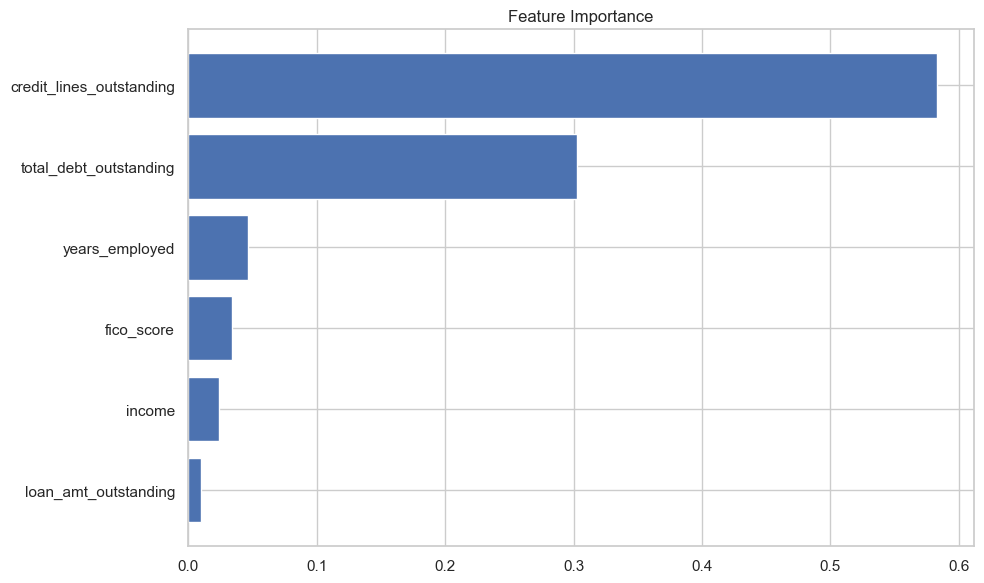

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Variable"],
    feature_importance["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()
plt.savefig("roc_curve.png")
plt.savefig("confusion_matrix.png")
plt.savefig("correlation_matrix.png")
plt.savefig("class_distribution.png")